# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Loading and Saving
from moments.bloch import (compute_bipartite_region_upper, compute_bipartite_region_ent, compute_bipartite_region_lower)
from moments.quantum import compute_negativity
from moments.saving import get_experiment_paths

data_dir, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

# Concurrence

# Importations and definitions

In [2]:
ent = np.load(data_dir / "concurrence.npz")
ent_max, ent_min = ent["max"], ent["min"]

Dt, Dz = ent_max.shape
t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

## Plots

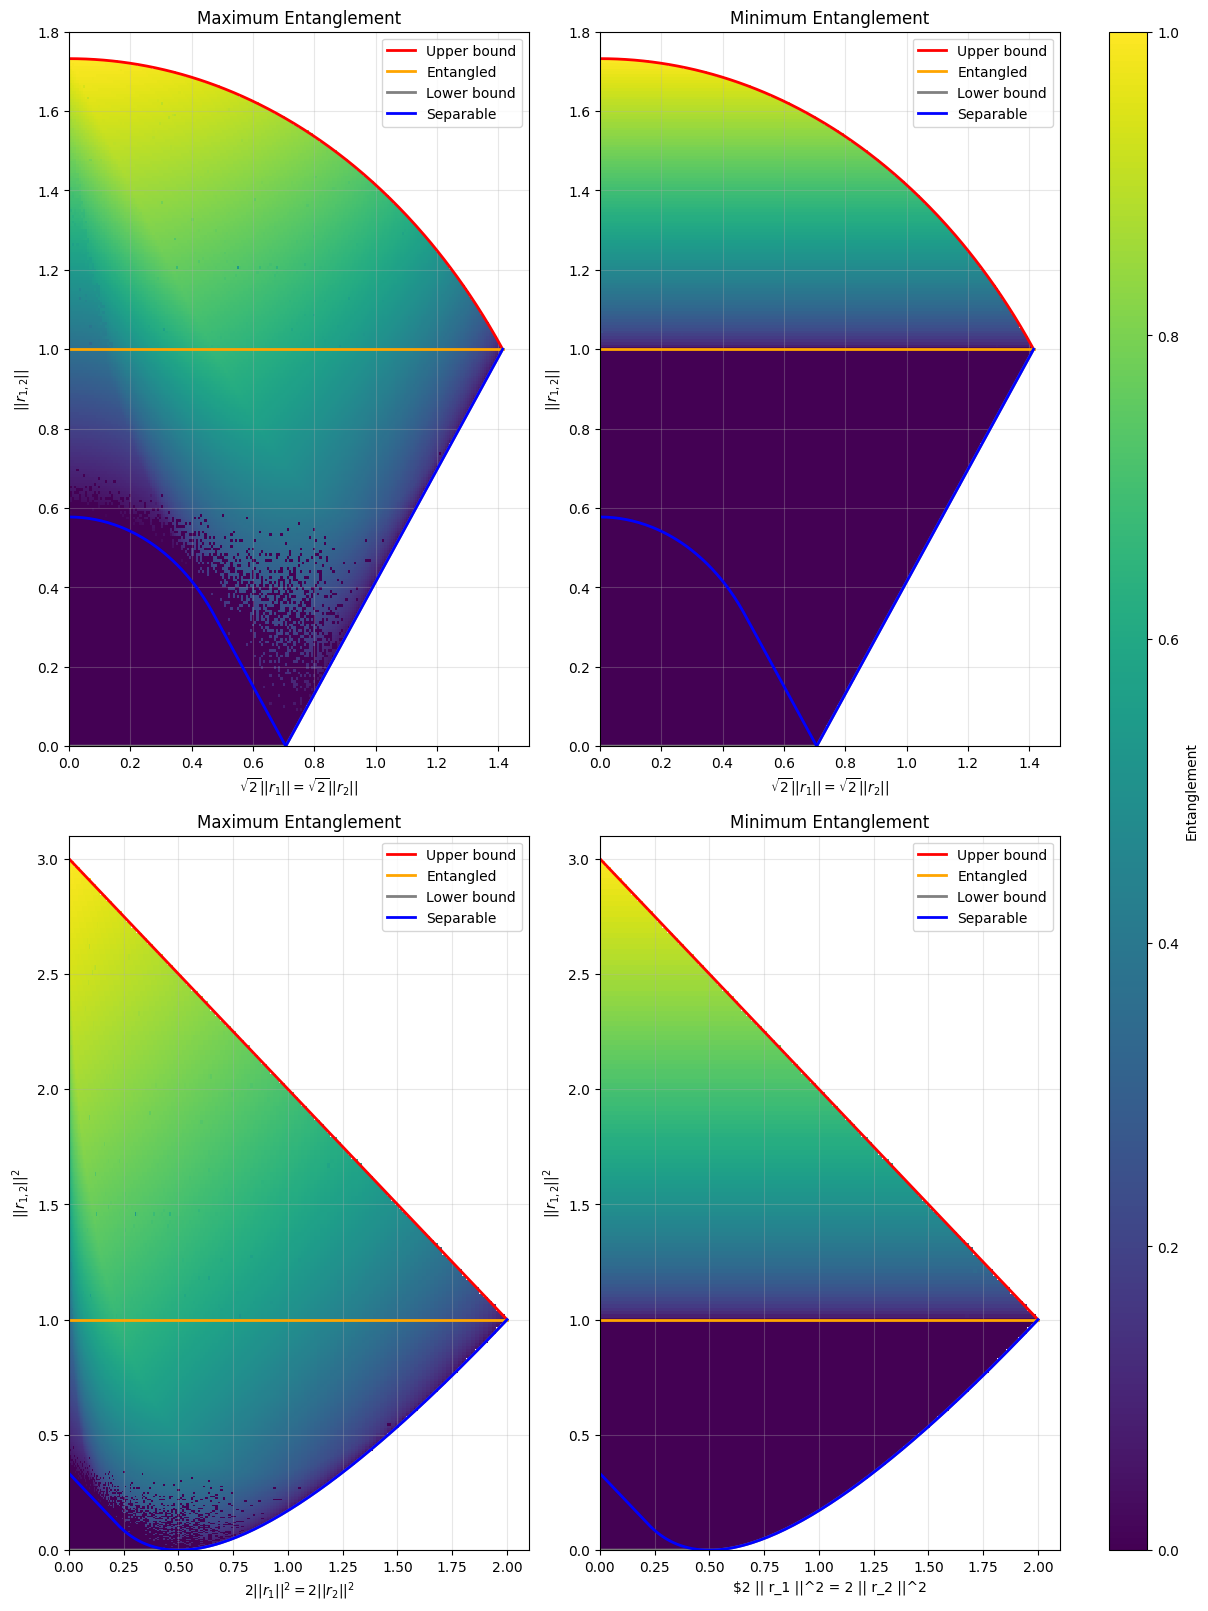

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)

mesh0 = ax[0, 0].pcolormesh(np.sqrt(2) * X, Z, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[0, 1].pcolormesh(np.sqrt(2) * X, Z, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh2 = ax[1, 0].pcolormesh(2 * X**2, Z**2, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh3 = ax[1, 1].pcolormesh(2 * X**2, Z**2, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=40, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0, 0].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.5), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[0, 1].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.5), ylim = (0, 1.8), title = "Minimum Entanglement")
ax[1, 0].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 2.1), ylim = (0, 3.1), title = "Maximum Entanglement")
ax[1, 1].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 2.1), ylim = (0, 3.1), title = "Minimum Entanglement")

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

ax[0, 0].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 0].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 0].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
ax[0, 0].plot(t, z_sep, 'blue', linewidth=2, label='Separable')

ax[0, 1].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 1].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 1].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
ax[0, 1].plot(t, z_sep, 'blue', linewidth=2, label='Separable')

ax[1, 0].plot(t**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 0].plot(t**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 0].plot(t**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')
ax[1, 0].plot(t**2, z_sep**2, 'blue', linewidth=2, label='Separable')

ax[1, 1].plot(t**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 1].plot(t**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 1].plot(t**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')
ax[1, 1].plot(t**2, z_sep**2, 'blue', linewidth=2, label='Separable')

ax[0, 0].legend(loc='upper right')
ax[0, 1].legend(loc='upper right')
ax[1, 0].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 1].grid(True, alpha=0.3)
ax[1, 0].grid(True, alpha=0.3)
ax[1, 1].grid(True, alpha=0.3)

plt.show()

# Negativity

## Importations and definitions

In [4]:
ent = np.load(data_dir / "trace_norm.npz")
ent_max = compute_negativity(trace_norm_pt=ent["max"])
ent_min = compute_negativity(trace_norm_pt=ent["min"])

Dt, Dz = ent["max"].shape
t = np.linspace(0, np.sqrt(2), Dt)
x = t / np.sqrt(2)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

## Plots

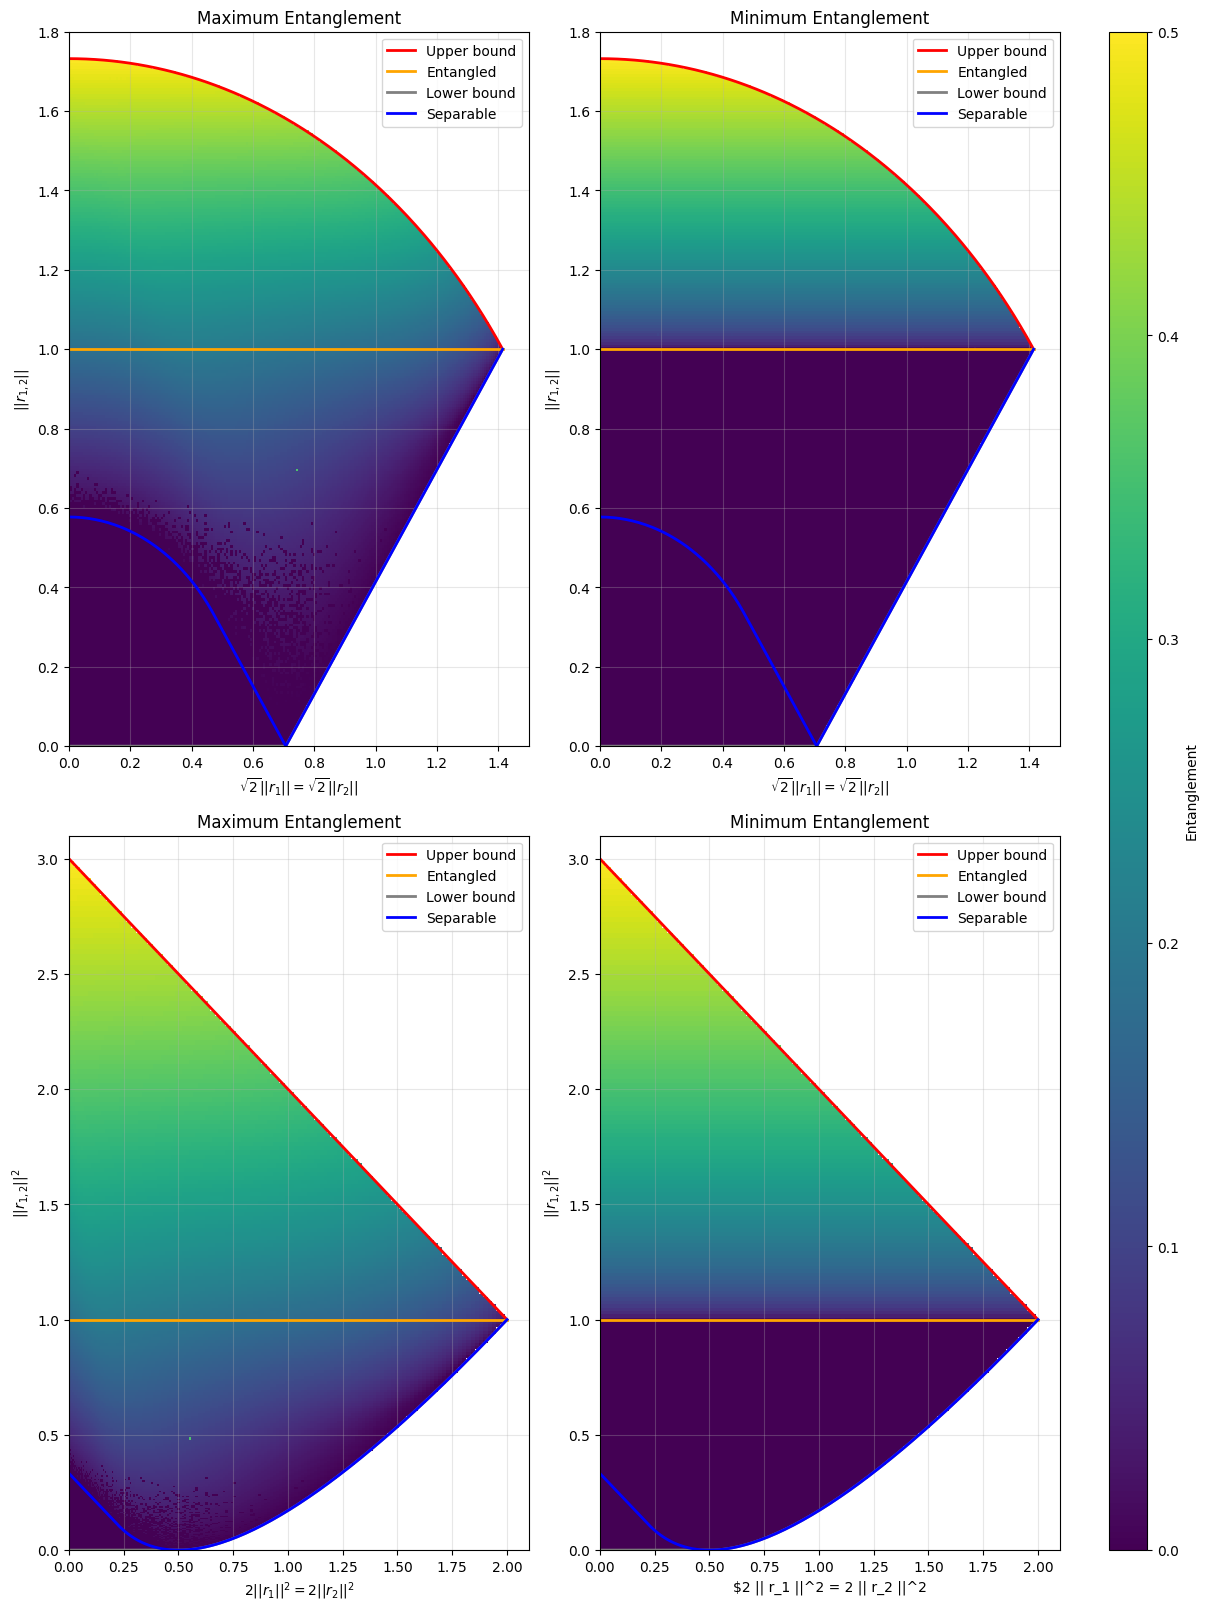

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12, 16), constrained_layout=True)

mesh0 = ax[0, 0].pcolormesh(np.sqrt(2) * X, Z, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh1 = ax[0, 1].pcolormesh(np.sqrt(2) * X, Z, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh2 = ax[1, 0].pcolormesh(2 * X**2, Z**2, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
mesh3 = ax[1, 1].pcolormesh(2 * X**2, Z**2, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=0.5)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=40, shrink=1)

cbar.set_ticks(list(np.linspace(0, 0.5, 6)))

ax[0, 0].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.5), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[0, 1].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
             xlim = (0, 1.5), ylim = (0, 1.8), title = "Minimum Entanglement")
ax[1, 0].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 2.1), ylim = (0, 3.1), title = "Maximum Entanglement")
ax[1, 1].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
             xlim = (0, 2.1), ylim = (0, 3.1), title = "Minimum Entanglement")

z_upper = compute_bipartite_region_upper(2, x, x)
z_ent = compute_bipartite_region_ent(2, x, x)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_lower = compute_bipartite_region_lower([2, 2], x, x)

ax[0, 0].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 0].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 0].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
ax[0, 0].plot(t, z_sep, 'blue', linewidth=2, label='Separable')

ax[0, 1].plot(t, z_upper, 'red', linewidth=2, label='Upper bound')
ax[0, 1].plot(t, z_ent, 'orange', linewidth=2, label='Entangled')
ax[0, 1].plot(t, z_lower, 'grey', linewidth=2, label='Lower bound')
ax[0, 1].plot(t, z_sep, 'blue', linewidth=2, label='Separable')

ax[1, 0].plot(t**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 0].plot(t**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 0].plot(t**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')
ax[1, 0].plot(t**2, z_sep**2, 'blue', linewidth=2, label='Separable')

ax[1, 1].plot(t**2, z_upper**2, 'red', linewidth=2, label='Upper bound')
ax[1, 1].plot(t**2, z_ent**2, 'orange', linewidth=2, label='Entangled')
ax[1, 1].plot(t**2, z_lower**2, 'grey', linewidth=2, label='Lower bound')
ax[1, 1].plot(t**2, z_sep**2, 'blue', linewidth=2, label='Separable')

ax[0, 0].legend(loc='upper right')
ax[0, 1].legend(loc='upper right')
ax[1, 0].legend(loc='upper right')
ax[1, 1].legend(loc='upper right')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 1].grid(True, alpha=0.3)
ax[1, 0].grid(True, alpha=0.3)
ax[1, 1].grid(True, alpha=0.3)

plt.show()